In [1]:
import json
import os
from pathlib import Path
from pprint import pprint
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
import xarray as xr

dirpath_repo_root = Path().resolve().parents[1]
dirpath_self = Path().resolve().parent
sys.path.append(str(dirpath_repo_root))
sys.path.append(str(dirpath_self))

from analysis.ou_tuning import batch_utils

### Common parameters

In [2]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/pops_inpsur_newsec_var_drxe_rxi'

dirpath_cfg = dirpath_repo_root / 'exp_configs' / exp_name
dirpath_res = dirpath_repo_root / 'exp_results' / exp_name

fname_data_templ = 'result_{job:05d}_*.json'

vars = {
    'rate': 'rates', 'cv': 'cvs',
    'vmin': 'v_med_min', 'vmax': 'v_med_max',
    'vavg': 'v_thresh_avg', 'vstd': 'v_thresh_std'
}

### Helper functions

In [10]:
def _get_fpath_by_templ(dirpath: Path, fname_templ: str) -> str:
    files = list(dirpath.glob(fname_templ))
    if len(files) != 1:
        print(f'Path for search: {str(dirpath)}')
        print(f'Name template: {fname_templ}')
        raise RuntimeError('Should be exactly one filename match')
    return files[0]

In [11]:
def load_job_idx(exp_name_sub):
    """Extract (param_grid -> job_id) xarray from cfg folder. """
    job_idx_xr = batch_utils.extract_batch_params_to_xr(
        dirpath_res / exp_name_sub / 'cfg',
        cfg_param_fields={'drxe_pos': 'drxe_num', 'rxi_pos': 'rxi_num'},
        fname_cfg_templ='cfg_*.json',
        job_pos_in_fname=1
    )
    if job_idx_xr.size == 0:
        raise RuntimeError('No cfg files found')
    return job_idx_xr


def load_regions(exp_label):
    """Load (drxe, rxi) regions. """
    fname_rgn = dirpath_cfg / f'regions_{exp_label}.json'
    with open(fname_rgn, 'r') as fid:
        regions = json.load(fid)['regions']
    return regions


def alloc_datasets(pops_used, vars, job_idx_xr, regions):
    """Allocate xarray Dataset for each population. """
    n_drxe = job_idx_xr.sizes['drxe_pos']
    n_rxi = job_idx_xr.sizes['rxi_pos']

    X = {}
    for pop in pops_used:
        # Create a Dataset
        X_ = {}
        for v in vars:
            X_[v] = xr.full_like(job_idx_xr, np.nan, dtype=np.float64)
        X_ = xr.Dataset(X_)

        # Region
        rgn = regions[pop]
        rxe0, rxi0 = rgn['rxe0'], rgn['rxi0']
        drxe, drxi = rgn['drxe'], rgn['drxi']
        drxe_vals = np.linspace(-drxe, 0, n_drxe)
        rxi_vals = np.linspace(rxi0, rxi0 + drxi, n_rxi)

        # Add drxe and rxi coords
        X_ = X_.assign_coords(
            drxe=('drxe_pos', drxe_vals),
            rxi=('rxi_pos', rxi_vals),
        )        
        X[pop] = X_

    return X


In [12]:
def load_data(X, job_idx_xr, exp_name_sub, vars, pops_used):
    """Load batch results into pre-allocated X (in-place). """
    
    # Iterate over all cells in job_idx_xr and fill X
    for idx in np.ndindex(job_idx_xr.shape):
        job_id = job_idx_xr.values[idx]
        if np.isnan(job_id):
            continue
        job_id = int(job_id)
        sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}
        
        # Generate file path for the job data
        fname_data = fname_data_templ.format(job=job_id)
        dirpath_data = dirpath_res / exp_name_sub / 'results'
        fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
        #print(job_id, fpath_data.name)

        # Load data and assign it to the corresponding slices in X
        with open(fpath_data, 'r') as fid:
            res = json.load(fid)
        for v, v_res in vars.items():
            for pop in pops_used:
                if pop in res[v_res]:
                    X[pop][v][sel] = res[v_res][pop]

    for pop in pops_used:
        X[pop] = X[pop].swap_dims({
            'drxe_pos': 'drxe',
            'rxi_pos': 'rxi',
        })

In [13]:
def upsample_and_smooth(da, coords_new, win):
    """Upsample and smooth while preserving the original NaN mask footprint. """
    da_up = da.interp(**coords_new)

    mask0 = da.notnull()
    mask_up = (
        mask0.astype(float)
        .interp(**coords_new, method='nearest')
        .astype(bool)
    )

    num = da_up.fillna(0).rolling(**win, center=True, min_periods=1).sum()
    den = da_up.notnull().astype(float).rolling(**win, center=True, min_periods=1).sum()

    out = num / den
    out = out.where(mask_up)
    return out


def find_contour(da, level, xname, yname):
    """Find and concatenate all contour segments. """
    x = da.coords[xname].values
    y = da.coords[yname].values
    Z = np.ma.masked_invalid(da.transpose(yname, xname).values)

    Xg, Yg = np.meshgrid(x, y)

    fig, ax = plt.subplots()
    cs = ax.contour(Xg, Yg, Z, levels=[level])
    plt.close(fig)

    segs = [seg for seg in cs.allsegs[0] if len(seg) > 0]
    pts = np.vstack(segs)
    seg_id = np.concatenate([np.full(len(seg), i) for i, seg in enumerate(segs)])

    return {
        'xy': pts,
        xname: pts[:, 0],
        yname: pts[:, 1],
        'seg_id': seg_id,
    }


def interp_on_points(da, pts, xname, yname):
    """Interpolate a variable on arbitrary points. """
    x = da.coords[xname].values
    y = da.coords[yname].values
    Z = np.asarray(da.transpose(yname, xname).values, dtype=float)

    interp = RegularGridInterpolator(
        (y, x), Z,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    return interp(np.c_[pts[:, 1], pts[:, 0]])


def split_by_seg(arr, seg_id):
    """Split a contour-aligned array into contour segments. """
    return [arr[seg_id == i] for i in np.unique(seg_id)]


def get_coord_bounds(X, xname, yname, k):
    x0 = float(X[xname].min()) * k
    x1 = float(X[xname].max()) * k
    y0 = float(X[yname].min()) * k
    y1 = float(X[yname].max()) * k
    return x0, x1, y0, y1


In [14]:
def prepare_maps(X, pop, r0, vars, n_grid=200, sm_win=71,
                 xname='drxe', yname='rxi', k=1):

    vars_used = list(vars.keys())
    X_pop = X[pop]

    # Compute coordinate bounds
    x0, x1, y0, y1 = get_coord_bounds(X_pop, xname, yname, k)

    # Build upsampled grid
    coords_new = {
        xname: np.linspace(x0, x1, n_grid),
        yname: np.linspace(y0, y1, n_grid),
    }

    # Define smoothing window
    win = {xname: sm_win, yname: sm_win}

    # Upsample and smooth all variables on the same grid
    X_up = {
        v: upsample_and_smooth(X_pop[v], coords_new, win)
        for v in vars_used
    }

    # Find the r=r0 contour on the upsampled rate map
    contour = find_contour(X_up['rate'], r0, xname, yname)

    # Sample all variables on the contour points
    for v in vars_used:
        contour[v] = interp_on_points(X_up[v], contour['xy'], xname, yname)

    # Find the contour point with maximal CV
    id_sel = np.nanargmax(contour['cv'])
    x_sel = contour[xname][id_sel]
    y_sel = contour[yname][id_sel]

    # Collect the results
    res = {
        'X_up': X_up, 'contour': contour,
        'id_sel': id_sel,
        'x_sel': x_sel, 'y_sel': y_sel,
        'par': {
            'pop': pop, 'r0': r0, 'xname': xname, 'yname': yname,
            'k': k, 'n_grid': n_grid, 'sm_win': sm_win
        }
    }
    return res

In [15]:
def plot_2d_map(
        fig, ax,
        maps, var,
        xlabel=True, ylabel=True,
        title=True, legend=True,
        transpose=True
        ):

    # Map, contour, chosen point
    X = maps['X_up'][var]
    contour = maps['contour']
    x_sel, y_sel = maps['x_sel'], maps['y_sel']

    par = maps['par']
    pop, r0 = par['pop'], par['r0']
    xname, yname, k = par['xname'], par['yname'], par['k']

    if transpose:
        xname, yname = yname, xname
        x_sel, y_sel = y_sel, x_sel

    # Compute coordinate bounds
    x0, x1, y0, y1 = get_coord_bounds(X, xname, yname, k)

    # Plot 2D map
    im = ax.imshow(
        X.transpose(xname, yname).values.T,
        extent=(x0, x1, y0, y1),
        aspect='auto',
        origin='lower',
        interpolation='bicubic'
    )

    # Plot contour: r=r0
    for xs, ys in zip(
            split_by_seg(contour[xname], contour['seg_id']),
            split_by_seg(contour[yname], contour['seg_id'])):
        ax.plot(xs, ys, 'k-', lw=2)

    # Plot chosen point
    ax.plot(x_sel, y_sel, 'ro')

    if title:
        ax.set_title(f'{pop}, {var}')
    if xlabel:
        ax.set_xlabel(xname)
    if ylabel:
        ax.set_ylabel(yname)
    if legend:
        ax.legend([f'r={r0:.01f} Hz'])
    
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    
    fig.colorbar(im, ax=ax, shrink=0.8)

In [16]:
def plot_1d_map(
        fig, ax,
        maps, var,
        xlabel=True, ylabel=True,
        title=True, legend=True
        ):

    # Map, contour, chosen point
    X = maps['X_up'][var]
    contour = maps['contour']
    id_sel = maps['id_sel']

    par = maps['par']
    pop, r0 = par['pop'], par['r0']
    yname = par['yname']

    xc = contour[yname]
    xc_max = xc[id_sel]

    # Plot variable along the contour
    for xs, ys in zip(
            split_by_seg(xc, contour['seg_id']),
            split_by_seg(contour[var], contour['seg_id'])):
        plt.plot(xs, ys, 'k.')

    # Plot chosen point
    plt.plot(xc_max, contour[var][id_sel], 'ro')

    if title:
        ax.set_title(f'{pop}, {var}')
    if xlabel:
        ax.set_xlabel(yname)
    if ylabel:
        ax.set_ylabel(var)
    if legend:
        #ax.legend([f'{var}, r={r0:.01f} Hz'])
        ax.legend([var])
    
    if var == 'rate':
        ax.set_ylim(r0 - 1, r0 + 1)

### Main

In [17]:
def plot_maps(maps):

    vars_vis = ['rate', 'cv', 'vavg']
    nvars = len(vars_vis)

    fig, axs = plt.subplots(2, nvars, figsize=(12, 8))

    for n, var in enumerate(vars_vis):
        # 2D map
        plt.subplot(2, nvars, n + 1)
        plot_2d_map(
            fig, axs[0, n], maps, var,
            xlabel=True, ylabel=(n == 0),
            title=True, legend=(n == 0)
        )
        # 1D plot
        plt.subplot(2, nvars, nvars + n + 1)
        plot_1d_map(
            fig, axs[1, n], maps, var,
            xlabel=True, ylabel=False,
            title=False, legend=True
        )

In [18]:
exp_label = 'pv'
pops_used = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']

exp_name_sub = (
    '2d_20x20_psp_0.5_xsec_soma_soma'
    f'/exp_{exp_label}_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
)

job_idx_xr = load_job_idx(exp_name_sub)
regions = load_regions(exp_label)
X = alloc_datasets(pops_used, vars, job_idx_xr, regions)
load_data(X, job_idx_xr, exp_name_sub, vars, pops_used)

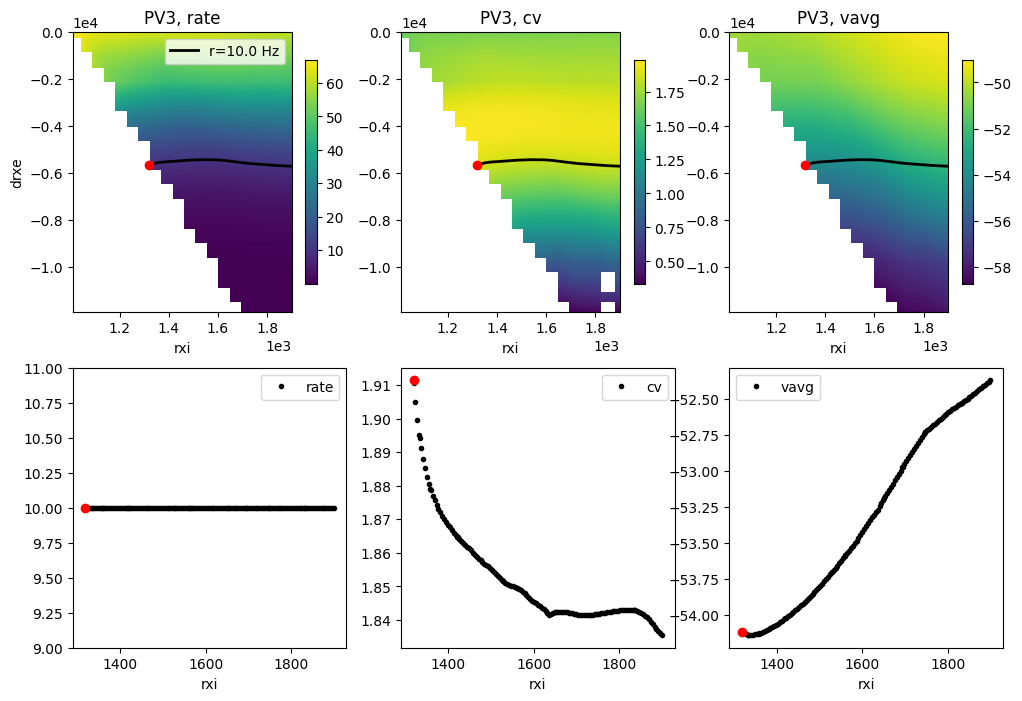

In [19]:
pop = 'PV3'
r0 = 10
maps = prepare_maps(X, pop, r0, vars)
plot_maps(maps)

In [ ]:
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_pv_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it2_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['IT2']
#exp_label = 'it2'

#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_pv_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
#exp_label = 'pv'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_som_sz_5_5_t_3.0_5.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_som_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
#exp_label = 'som'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_vip_sz_5_5_t_3.0_5.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_vip_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
#exp_label = 'vip'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_ngf_sz_5_5_t_3.0_5.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']
#exp_label = 'ngf'


### Old

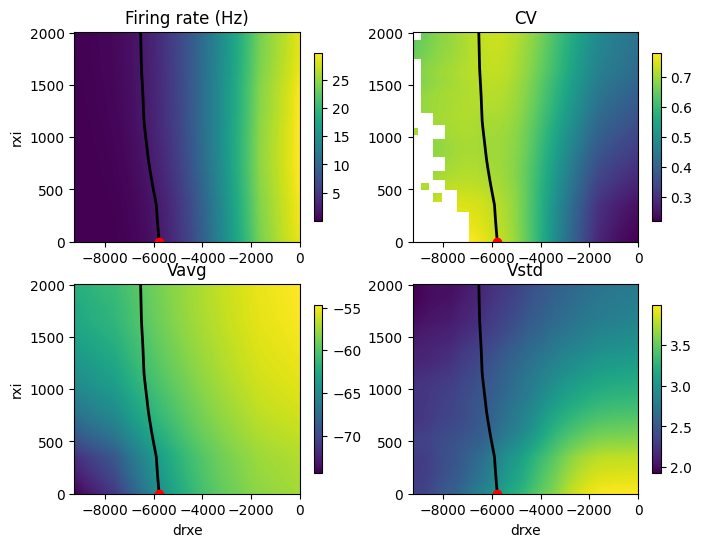

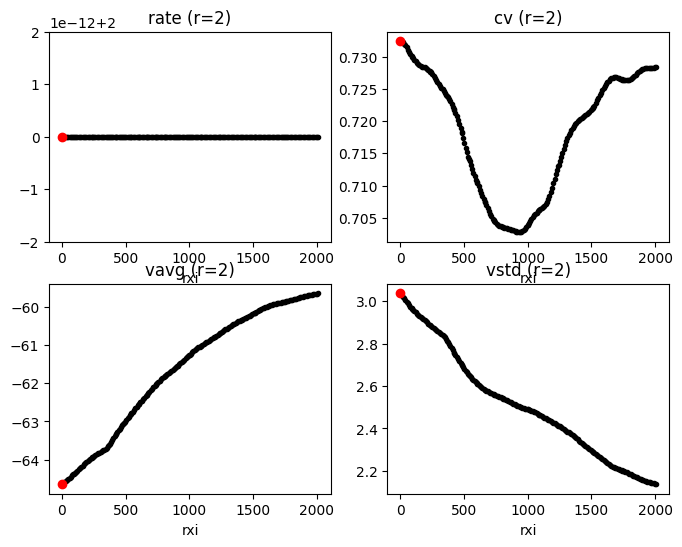

In [ ]:
vars_2d = [
    ('Firing rate (Hz)', 'rate'),
    ('CV', 'cv'),
    ('Vavg', 'vavg'),
    ('Vstd', 'vstd'),
]
vars_1d = [
    (f'rate (r={r0})', 'rate'),
    (f'cv (r={r0})', 'cv'),
    (f'vavg (r={r0})', 'vavg'),
    (f'vstd (r={r0})', 'vstd'),
]

# Plot 2D maps with contour and max-CV point
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

for ax, (title, v) in zip(axs.ravel(), vars_2d):
    da = X_up[v]
    

# Label 2D axes
for n in range(2):
    axs[1, n].set_xlabel(xname)
    axs[n, 0].set_ylabel(yname)


# Plot variables along the contour
plt.figure(figsize=(8, 6))





In [ ]:
drxe_sel, rxi_sel = res['xmax'], res['ymax']

rxe_sel = rgn['rxe0'] + (rxi_sel - rgn['rxi0']) / rgn['rxi_rxe_slope'] + drxe_sel
print(f'rxe={rxe_sel:.0f}, rxi={rxi_sel:.0f}')

rxe=3706, rxi=0
